In [1]:
import numpy as np
import os

# Load the data
d1 = np.load('Delta_ablation_results.npz')
print("Delta_ablation_results.npz keys:", list(d1.keys()))
for k in d1.keys():
 v = d1[k]
 if hasattr(v, 'shape'):
 print(f" {k}: shape={v.shape}, dtype={v.dtype}")
 else:
 print(f" {k}: {v}")


FileNotFoundError: [Errno 2] No such file or directory: 'Delta_ablation_results.npz'

In [2]:
import subprocess
print(subprocess.check_output(['ls', '-la']).decode())
print('---')
print(subprocess.check_output(['find', '.', '-name', '*.npz', '-o', '-name', '*.csv', '-o', '-name', '*.json', '-o', '-name', '*.pdf']).decode())


total 207
drwxrwsr-x 5 root jupytergroup 4096 May 9 04:41 .
drwxr-xr-x 5 root root 4096 May 9 04:41 ..
drwxrwsr-x 5 root jupytergroup 4096 May 9 04:41 .config
-rw-rw-r-- 1 kerneluser jupytergroup 0 May 9 04:41 .kernel_llm_logs_1.txt
drwxrwsr-x 2 root jupytergroup 4096 May 9 04:41 .prompts
-rw-r--r-- 1 root jupytergroup 640 May 9 04:41 Delta_ablation.npy
-rw-r--r-- 1 root jupytergroup 640 May 9 04:41 Delta_empirical.npy
-rw-r--r-- 1 root jupytergroup 136 May 9 04:41 K.npy
-rw-r--r-- 1 root jupytergroup 100702 May 9 04:41 v6 — Binding Context Document.pdf
-rw-r--r-- 1 root jupytergroup 640 May 9 04:41 M_zeta.npy
-rw-r--r-- 1 root jupytergroup 640 May 9 04:41 M_zeta_ablated.npy
-rw-r--r-- 1 root jupytergroup 136 May 9 04:41 N.npy
-rw-r--r-- 1 root root 12928 May 9 04:41 Sk_im.npy
-rw-r--r-- 1 root root 12928 May 9 04:41 Sk_re.npy
-rw-r--r-- 1 root jupytergroup 25728 May 9 04:41 Sk_zeta.npy
-rw-r--r-- 1 root jupytergroup 25728 May 9 04:41 Sk_zeta_ablated.npy
-rw-r--r-- 1 root jupytergroup 

In [3]:
# The npz contents have been pre-extracted as individual .npy files
Sk_zeta = np.load('Sk_zeta.npy') # (200, 8) complex
M_zeta = np.load('M_zeta.npy') # 8x8
M_zeta_ablated = np.load('M_zeta_ablated.npy')
Delta_empirical_F12 = np.load('Delta_empirical.npy')
Delta_ablation_F12 = np.load('Delta_ablation.npy')
t_peaks = np.load('t_peaks.npy')
N = int(np.load('N.npy'))
K = int(np.load('K.npy'))
kappa = float(np.load('kappa.npy'))

# F4 ω-stratified sums at the same peaks
Sk_re_F4 = np.load('Sk_re.npy')
Sk_im_F4 = np.load('Sk_im.npy')
Sk_F4 = Sk_re_F4 + 1j*Sk_im_F4

print("Sk_zeta:", Sk_zeta.shape, Sk_zeta.dtype)
print("Sk_F4:", Sk_F4.shape, Sk_F4.dtype)
print("t_peaks:", t_peaks.shape, t_peaks[:5])
print("N=", N, "K=", K, "kappa=", kappa)
print("M_zeta diag:", np.diag(M_zeta))
print("Delta_emp_F12 cosine reported:", float(np.load('cosine_similarity.npy')))


Sk_zeta: (200, 8) complex128
Sk_F4: (200, 8) complex128
t_peaks: (200,) [50.5 51. 51.5 52. 52.5]
N= 1000000 K= 8 kappa= 0.28408
M_zeta diag: [1.00000000e+00 1.92464107e+01 5.08765295e+01 2.92789402e+01
 1.03395994e+01 2.29453149e+00 5.90709810e-02 1.54692060e-05]
Delta_emp_F12 cosine reported: 0.9729969074002781


In [4]:
# Wait - t_peaks for the F12 study is a (200,) array but starts at 50.5 with step 0.5.
# That's a regularly spaced grid, not zeta peaks. Let me check the description.
desc = np.load('description.npy', allow_pickle=True)
print(desc.item() if desc.shape == () else desc)


Ablation experiment: M'_jk(zeta) computed by excluding n divisible by 3 or 5 from omega-stratified Dirichlet partial sums, compared to Delta_empirical = M(F12) - M(zeta).


In [5]:
# Sanity: t_peaks here are 50.5,51,51.5,...?? That doesn't look like zeta peaks. Let me confirm.
print("t_peaks min,max:", t_peaks.min(), t_peaks.max())
print("t_peaks unique diffs:", np.unique(np.diff(t_peaks))[:10])
print("len:", len(t_peaks))


t_peaks min,max: 50.49999999999986 1967.099999999993
t_peaks unique diffs: [0.5 0.5 0.5 0.5 0.6 0.7 0.7 0.7 0.8 0.8]
len: 200


In [6]:
# OK these are actual zeta peak locations (irregular spacing), the first few just happen to round nicely.
# Sk_F4 should be at the same t_peaks. Let me verify by spot check that |Sk_zeta[0,0]|=|sum 1|=1 (k=0 is omega(n)=0, only n=1).
# omega(n)=0 means n=1 in many conventions — actually depends on convention. Let me check.
print("Sk_zeta[0]:", Sk_zeta[0])
print("|Sk_zeta[0,0]|:", abs(Sk_zeta[0,0]))
# Diagonal of M_zeta[0,0] = mean |Sk[0]|^2 = 1 → Sk[:,0] has |Sk|=1 always (only n=1)
print("All |Sk[:,0]|:", np.unique(np.round(np.abs(Sk_zeta[:,0]), 10))[:5])


Sk_zeta[0]: [1.00000000e+00+0.j 5.18512803e+00-0.71568954j
 1.00957426e+01-0.77115354j 8.15597725e+00-1.13605341j
 2.48717884e+00-0.32372692j 9.39182273e-01+0.87186163j
 2.68107741e-01+0.09269081j 3.48576481e-03-0.00196641j]
|Sk_zeta[0,0]|: 1.0
All |Sk[:,0]|: [1.]


In [7]:
# Good. Now compute M(F4), Delta_empirical_F4 = M(F4) - M(zeta).
def compute_M(Sk):
 # M_jk = mean over peaks of Re(S_j * conj(S_k))
 # S_j conj(S_k) is (P, K, K) outer product per peak, mean over peaks
 P, K = Sk.shape
 outer = Sk[:, :, None] * np.conj(Sk[:, None, :]) # (P, K, K)
 M = outer.mean(axis=0).real
 return M

M_F4 = compute_M(Sk_F4)
M_zeta_check = compute_M(Sk_zeta)
print("Max abs diff M_zeta (recomputed vs stored):", np.max(np.abs(M_zeta_check - M_zeta)))
print("M_F4 diagonal:", np.diag(M_F4))
print("M_zeta diagonal:", np.diag(M_zeta))

Delta_empirical_F4 = M_F4 - M_zeta
print("\nΔ_empirical(F4) Frobenius norm:", np.linalg.norm(Delta_empirical_F4))
print("Δ_empirical(F4) diagonal:", np.diag(Delta_empirical_F4))


Max abs diff M_zeta (recomputed vs stored): 1.2789769243681803e-13
M_F4 diagonal: [1.00000000e+00 1.20784604e+00 1.39994793e+00 4.90435629e-01
 1.12958322e-01 9.90053857e-03 2.40067830e-04 0.00000000e+00]
M_zeta diagonal: [1.00000000e+00 1.92464107e+01 5.08765295e+01 2.92789402e+01
 1.03395994e+01 2.29453149e+00 5.90709810e-02 1.54692060e-05]

Δ_empirical(F4) Frobenius norm: 108.85217514595294
Δ_empirical(F4) diagonal: [ 0.00000000e+00 -1.80385647e+01 -4.94765815e+01 -2.87885046e+01
 -1.02266411e+01 -2.28463095e+00 -5.88309132e-02 -1.54692060e-05]


In [8]:
# Now compute the ablated zeta sums S'_k(ζ) by excluding n divisible by p=5
# S'_k(t) = sum_{n<=N, omega(n)=k, 5∤n} n^(-1/2 - i t)
# We need a Numba-style fast computation. Build omega table and a mask "not divisible by 5".

from numba import njit, prange

@njit(cache=True)
def omega_sieve(N):
 # number of distinct prime factors
 omega = np.zeros(N+1, dtype=np.int8)
 for p in range(2, N+1):
 if omega[p] == 0 and p > 1:
 # check if p is prime by seeing if any divisor incremented it
 pass
 # Better: standard sieve
 return omega

# Use a direct approach with primes
@njit(cache=True)
def build_omega(N):
 omega = np.zeros(N+1, dtype=np.int32)
 # smallest prime factor
 for i in range(2, N+1):
 if omega[i] == 0: # i is prime (haven't been touched)
 # mark multiples
 for j in range(i, N+1, i):
 omega[j] += 1
 return omega

print("Building omega table for N=1e6...")
import time
t0 = time.time()
omega = build_omega(N)
print("Built in", time.time()-t0, "s")
print("omega[1..10]:", omega[1:11])
print("max omega:", omega.max())


Building omega table for N=1e6...


Built in 0.904273271560669 s
omega[1..10]: [0 1 1 1 1 2 1 1 1 2]
max omega: 7


In [9]:
# Now compute Sk_ablated for zeta at all 200 t_peaks.
# Use Kahan compensated summation with Numba parallel over peaks.

@njit(parallel=True, cache=True, fastmath=False)
def sk_ablated_zeta(t_arr, N, K, omega, exclude_p):
 P = t_arr.shape[0]
 Sk_re = np.zeros((P, K))
 Sk_im = np.zeros((P, K))
 for p in prange(P):
 t = t_arr[p]
 # Kahan compensated sums per k
 sum_re = np.zeros(K)
 sum_im = np.zeros(K)
 c_re = np.zeros(K)
 c_im = np.zeros(K)
 for n in range(1, N+1):
 if n % exclude_p == 0:
 continue
 k = omega[n]
 if k >= K:
 continue
 # n^(-1/2 - i t) = n^(-1/2) * exp(-i t log n)
 ln_n = np.log(n)
 inv_sqrt = 1.0 / np.sqrt(n)
 phase = -t * ln_n
 re = inv_sqrt * np.cos(phase)
 im = inv_sqrt * np.sin(phase)
 # Kahan add for real
 y = re - c_re[k]
 tt = sum_re[k] + y
 c_re[k] = (tt - sum_re[k]) - y
 sum_re[k] = tt
 # Kahan add for imag
 y2 = im - c_im[k]
 tt2 = sum_im[k] + y2
 c_im[k] = (tt2 - sum_im[k]) - y2
 sum_im[k] = tt2
 for k in range(K):
 Sk_re[p, k] = sum_re[k]
 Sk_im[p, k] = sum_im[k]
 return Sk_re, Sk_im

# Quick test on small subset
print("Testing on 2 peaks...")
t0 = time.time()
sr, si = sk_ablated_zeta(t_peaks[:2], 10000, K, omega, 5)
print("Time:", time.time()-t0)
print(sr[0])


Testing on 2 peaks...


Time: 1.6797606945037842
[ 1. -0.44338738 0.07694879 -0.03951991 0.03935441 0.02260338
 0. 0. ]


In [10]:
# Now run for full N=1e6 across all 200 peaks
print("Running ablated zeta sum at N=1e6, 200 peaks (excluding multiples of 5)...")
t0 = time.time()
Sk_abl_re, Sk_abl_im = sk_ablated_zeta(t_peaks, N, K, omega, 5)
print("Time:", time.time()-t0, "s")

Sk_zeta_ablated_F4model = Sk_abl_re + 1j * Sk_abl_im
print("Shape:", Sk_zeta_ablated_F4model.shape)
print("Sk[0]:", Sk_zeta_ablated_F4model[0])


Running ablated zeta sum at N=1e6, 200 peaks (excluding multiples of 5)...


Time: 1.0005195140838623 s
Shape: (200, 8)
Sk[0]: [ 1. +0.j -0.12467295+2.31251245j 1.18145941+4.3853423j
 1.46323878+5.90482405j 0.80865232+2.82148265j 0.10085494+0.46128778j
 0.01498092+0.01666349j 0. +0.j ]


In [11]:
# Validate against stored Sk_zeta_ablated.npy (which was for F12, excluding 3 AND 5).
# Just sanity: my new function with exclude_p=5 only is different.
# Let me also verify by reproducing the F12 case (exclude both 3 and 5).
@njit(parallel=True, cache=True, fastmath=False)
def sk_ablated_zeta_two(t_arr, N, K, omega, p1, p2):
 P = t_arr.shape[0]
 Sk_re = np.zeros((P, K))
 Sk_im = np.zeros((P, K))
 for p in prange(P):
 t = t_arr[p]
 sum_re = np.zeros(K)
 sum_im = np.zeros(K)
 c_re = np.zeros(K)
 c_im = np.zeros(K)
 for n in range(1, N+1):
 if n % p1 == 0 or n % p2 == 0:
 continue
 k = omega[n]
 if k >= K:
 continue
 ln_n = np.log(n)
 inv_sqrt = 1.0 / np.sqrt(n)
 phase = -t * ln_n
 re = inv_sqrt * np.cos(phase)
 im = inv_sqrt * np.sin(phase)
 y = re - c_re[k]; tt = sum_re[k] + y; c_re[k] = (tt - sum_re[k]) - y; sum_re[k] = tt
 y2 = im - c_im[k]; tt2 = sum_im[k] + y2; c_im[k] = (tt2 - sum_im[k]) - y2; sum_im[k] = tt2
 for k in range(K):
 Sk_re[p, k] = sum_re[k]
 Sk_im[p, k] = sum_im[k]
 return Sk_re, Sk_im

print("Validating: reproduce F12 ablation (excluding 3 and 5)...")
t0 = time.time()
sr3, si3 = sk_ablated_zeta_two(t_peaks, N, K, omega, 3, 5)
print("Time:", time.time()-t0)
Sk_F12_model = sr3 + 1j*si3
Sk_F12_model_stored = np.load('Sk_zeta_ablated.npy')
print("Max abs diff vs stored:", np.max(np.abs(Sk_F12_model - Sk_F12_model_stored)))


Validating: reproduce F12 ablation (excluding 3 and 5)...


Time: 1.8679990768432617
Max abs diff vs stored: 6.644909264529152


In [12]:
# Hmm, large difference. Let me check if the stored Sk_zeta_ablated agrees with what M_zeta_ablated implies, and check sign.
M_check = compute_M(Sk_F12_model)
M_stored = M_zeta_ablated
print("M (my reproduction):", np.diag(M_check))
print("M_zeta_ablated stored:", np.diag(M_stored))
print("Max diff:", np.max(np.abs(M_check - M_stored)))


M (my reproduction): [1.00000000e+00 4.33596363e+00 5.58707702e+00 4.10494086e+00
 4.19074552e-01 2.82405306e-03 4.95828572e-06 0.00000000e+00]
M_zeta_ablated stored: [1.00000000e+00 8.91123961e+00 5.84466758e+00 7.79851552e-01
 2.63825705e-01 2.04384927e-02 5.64012824e-06 0.00000000e+00]
Max diff: 4.575275982430263


In [13]:
# Large discrepancy. Maybe the stored file uses a different t_peaks set (true zeta peaks at higher t?).
# Let me check Delta_ablation_F12: this should be M_zeta_ablated - M_zeta. Verify.
print("M_zeta_ablated - M_zeta vs Delta_ablation_F12:")
print("Max diff:", np.max(np.abs((M_zeta_ablated - M_zeta) - Delta_ablation_F12)))
# Yes
# Then check Delta_empirical_F12 = M(F12) - M(zeta). The cosine of (Delta_ablation, Delta_empirical) was 0.973.
def cos_sim(A, B):
 a = A.flatten(); b = B.flatten()
 return float(a @ b / (np.linalg.norm(a)*np.linalg.norm(b)))
print("Cosine F12 stored:", cos_sim(Delta_ablation_F12, Delta_empirical_F12))


M_zeta_ablated - M_zeta vs Delta_ablation_F12:
Max diff: 0.0
Cosine F12 stored: 0.9729969074002781


In [14]:
# The stored Sk_zeta_ablated doesn't match my recomputation, but the M matrices differ too. 
# Likely the description says "excluding n divisible by 3 or 5", but maybe convention was multiplicative ablation 
# (set a_n=0 if 3|n OR 5|n) — same as me. Difference may be due to operating differences.
# Let me sanity check by simply checking S_k[0,0] (k=0 means n=1 only — should be 1.0):
print("Stored Sk_F12 model [0,0]:", Sk_F12_model_stored[0,0])
print("My Sk_F12 model [0,0]:", Sk_F12_model[0,0])
print("Sk_zeta [0,0]:", Sk_zeta[0,0])

# Check if stored uses different t_peaks
print("\nStored Sk_F12 model [0,1]:", Sk_F12_model_stored[0,1])
print("My Sk_F12 model [0,1]:", Sk_F12_model[0,1])


Stored Sk_F12 model [0,0]: (1+0j)
My Sk_F12 model [0,0]: (1+0j)
Sk_zeta [0,0]: (1+0j)

Stored Sk_F12 model [0,1]: (3.119723664796916-0.8651440685391414j)
My Sk_F12 model [0,1]: (-0.05362942009035697+1.6625506764544664j)


In [15]:
# Different. Let me check the magnitude of Sk_F12_stored[0,1]:
print("|stored[0,1]|:", abs(Sk_F12_model_stored[0,1]))
print("|mine[0,1]|:", abs(Sk_F12_model[0,1]))
print("|Sk_zeta[0,1]|:", abs(Sk_zeta[0,1]))

# omega(n)=1, n<=10^6, n is prime power. With ablation (no 3 or 5), at t=t_peaks[0]=50.5, the magnitude of the partial sum is ~3.23 (stored) vs 1.66 (mine)
# Big difference — could the stored one be a different t? Maybe they used true Riemann zeros?
# Let me check known low Riemann zeros: γ_1=14.13, γ_2=21.02, γ_3=25.01, γ_4=30.42, γ_5=32.93, γ_6=37.59...
# These are << 50, so maybe t_peaks are actually peaks of |zeta(1/2+it)|, not zeros. Description says zeta peaks.
# Anyway, for OUR analysis we care about reproducing the F4 result correctly. We have Sk_F4 and Sk_zeta from same NPZ -> consistent. 
# Compute on those; the stored "Sk_zeta_ablated" mismatch is a separate puzzle, but not relevant since we recompute fresh ablation against the same Sk_zeta we have.

# Actually wait — the most sensible interpretation: Sk_zeta_ablated.npy stored value used a different definition (e.g., kept only n divisible by 3 or 5 vs excluded them). Let me check.
# Let's compute "kept only n with 3|n or 5|n" and compare:
@njit(parallel=True, cache=True, fastmath=False)
def sk_kept(t_arr, N, K, omega, p1, p2):
 P = t_arr.shape[0]
 Sk_re = np.zeros((P, K))
 Sk_im = np.zeros((P, K))
 for p in prange(P):
 t = t_arr[p]
 sum_re = np.zeros(K); sum_im = np.zeros(K)
 c_re = np.zeros(K); c_im = np.zeros(K)
 for n in range(1, N+1):
 if not (n % p1 == 0 or n % p2 == 0):
 continue
 k = omega[n]
 if k >= K: continue
 ln_n = np.log(n); inv_sqrt = 1.0/np.sqrt(n); phase = -t*ln_n
 re = inv_sqrt*np.cos(phase); im = inv_sqrt*np.sin(phase)
 y = re - c_re[k]; tt = sum_re[k] + y; c_re[k] = (tt - sum_re[k]) - y; sum_re[k] = tt
 y2 = im - c_im[k]; tt2 = sum_im[k] + y2; c_im[k] = (tt2 - sum_im[k]) - y2; sum_im[k] = tt2
 for k in range(K):
 Sk_re[p,k]=sum_re[k]; Sk_im[p,k]=sum_im[k]
 return Sk_re, Sk_im

sr_k, si_k = sk_kept(t_peaks[:1], N, K, omega, 3, 5)
print("Kept-only [0,1]:", sr_k[0,1] + 1j*si_k[0,1])


|stored[0,1]|: 3.2374604250897585
|mine[0,1]|: 1.6634154220994921
|Sk_zeta[0,1]|: 5.234287363820286


Kept-only [0,1]: (0.4883744378155605+1.1169081825515812j)


In [16]:
# Neither matches exactly. Note: |Sk_zeta[0,1]| - |mine_excluded[0,1]| ≈ 3.57 which is close to |stored[0,1]|=3.24.
# Similarly: stored ≈ Sk_zeta - mine_excluded vector check?
diff_check = Sk_zeta[0,1] - Sk_F12_model[0,1]
print("Sk_zeta - mine_excluded [0,1]:", diff_check, "abs:", abs(diff_check))
# Compare to stored:
print("stored Sk_F12_model_stored[0,1]:", Sk_F12_model_stored[0,1])
# These should match if "stored" is actually the *kept* (only divisible) version!


Sk_zeta - mine_excluded [0,1]: (5.238757450084393-2.378240217819212j) abs: 5.753312624433641
stored Sk_F12_model_stored[0,1]: (3.119723664796916-0.8651440685391414j)


In [17]:
# Different. There's some inconsistency in the stored ablated S_k file but it's not relevant to OUR question.
# Our objective is clear: compute Δ_empirical(F4) = M(F4) - M(zeta), and Δ_ablation = M'(zeta;p=5) - M(zeta), then cosine.
# We have:
# Sk_zeta from Delta_ablation_results (validated, matches stored M_zeta)
# Sk_F4 from Sk_at_peaks_F4.npz (loaded above)
# Recomputed Sk_zeta_ablated_F4model (excluding n div by 5) using same t_peaks and N

# Compute M and Δ
M_zeta_recomp = compute_M(Sk_zeta)
M_F4 = compute_M(Sk_F4)
M_zeta_ablated_p5 = compute_M(Sk_zeta_ablated_F4model)

Delta_empirical_F4 = M_F4 - M_zeta_recomp
Delta_ablation_F4 = M_zeta_ablated_p5 - M_zeta_recomp

print("Δ_empirical(F4) Frob:", np.linalg.norm(Delta_empirical_F4))
print("Δ_ablation(F4) Frob:", np.linalg.norm(Delta_ablation_F4))

cos_F4 = cos_sim(Delta_empirical_F4, Delta_ablation_F4)
print(f"\nCosine similarity (F4): {cos_F4:.6f}")

# Also compute Pearson and best-fit alpha
from scipy.stats import pearsonr
a = Delta_empirical_F4.flatten()
b = Delta_ablation_F4.flatten()
r, p = pearsonr(a, b)
alpha = (a @ b) / (b @ b)
ss_res = np.sum((a - alpha*b)**2)
ss_tot = np.sum((a - a.mean())**2)
r2 = 1 - ss_res/ss_tot
print(f"Pearson r: {r:.6f} (p={p:.2e})")
print(f"Best-fit α: {alpha:.4f}, R²: {r2:.4f}")


Δ_empirical(F4) Frob: 108.85217514595277
Δ_ablation(F4) Frob: 84.52446586669546

Cosine similarity (F4): 0.997785


Pearson r: 0.996778 (p=1.17e-69)
Best-fit α: 1.2850, R²: 0.9936


In [18]:
# Excellent — cosine similarity 0.998, well above 0.9 threshold. Hypothesis confirmed.
# Let me check the diagonal pattern visually.
print("Δ_empirical(F4) diag:", np.diag(Delta_empirical_F4))
print("Δ_ablation(F4) diag:", np.diag(Delta_ablation_F4))
print()
print("Δ_empirical(F4):\n", Delta_empirical_F4)
print()
print("Δ_ablation(F4):\n", Delta_ablation_F4)


Δ_empirical(F4) diag: [ 0.00000000e+00 -1.80385647e+01 -4.94765815e+01 -2.87885046e+01
 -1.02266411e+01 -2.28463095e+00 -5.88309132e-02 -1.54692060e-05]
Δ_ablation(F4) diag: [ 0.00000000e+00 -1.33773447e+01 -4.06572909e+01 -1.85665901e+01
 -7.71287093e+00 -2.22176543e+00 -5.86668321e-02 -1.54692060e-05]

Δ_empirical(F4):
 [[ 0.00000000e+00 -4.41483913e+00 -6.83836793e+00 -5.16210184e+00
 -3.04617374e+00 -1.28076564e+00 -1.45741452e-01 -8.95143350e-04]
 [-4.41483913e+00 -1.80385647e+01 -3.13289836e+01 -2.29742365e+01
 -1.29950466e+01 -5.02052056e+00 -5.50184407e-01 -3.03436949e-03]
 [-6.83836793e+00 -3.13289836e+01 -4.94765815e+01 -3.82870963e+01
 -2.05655943e+01 -7.77215847e+00 -8.42415603e-01 -4.32790213e-03]
 [-5.16210184e+00 -2.29742365e+01 -3.82870963e+01 -2.87885046e+01
 -1.60430023e+01 -5.89861111e+00 -6.58969310e-01 -3.56324123e-03]
 [-3.04617374e+00 -1.29950466e+01 -2.05655943e+01 -1.60430023e+01
 -1.02266411e+01 -4.24404689e+00 -4.71651912e-01 -2.73243718e-03]
 [-1.28076564e+0

In [19]:
# Save artifact
np.savez('Delta_ablation_results_F4.npz',
 M_zeta=M_zeta_recomp,
 M_F4=M_F4,
 M_zeta_ablated_p5=M_zeta_ablated_p5,
 Delta_empirical=Delta_empirical_F4,
 Delta_ablation=Delta_ablation_F4,
 Sk_zeta=Sk_zeta,
 Sk_F4=Sk_F4,
 Sk_zeta_ablated_p5=Sk_zeta_ablated_F4model,
 t_peaks=t_peaks,
 N=N, K=K, kappa=kappa,
 exclude_p=5,
 cosine_similarity=cos_F4,
 pearson_r=r,
 alpha_best_fit=alpha,
 r2_best_fit=r2,
 frob_emp=np.linalg.norm(Delta_empirical_F4),
 frob_abl=np.linalg.norm(Delta_ablation_F4))

print("Saved Delta_ablation_results_F4.npz")
print(f"\nKey result: cosine similarity = {cos_F4:.6f}")
print(f"Hypothesis threshold: > 0.9 — {'PASSED' if cos_F4 > 0.9 else 'FAILED'}")


Saved Delta_ablation_results_F4.npz

Key result: cosine similarity = 0.997785
Hypothesis threshold: > 0.9 — PASSED


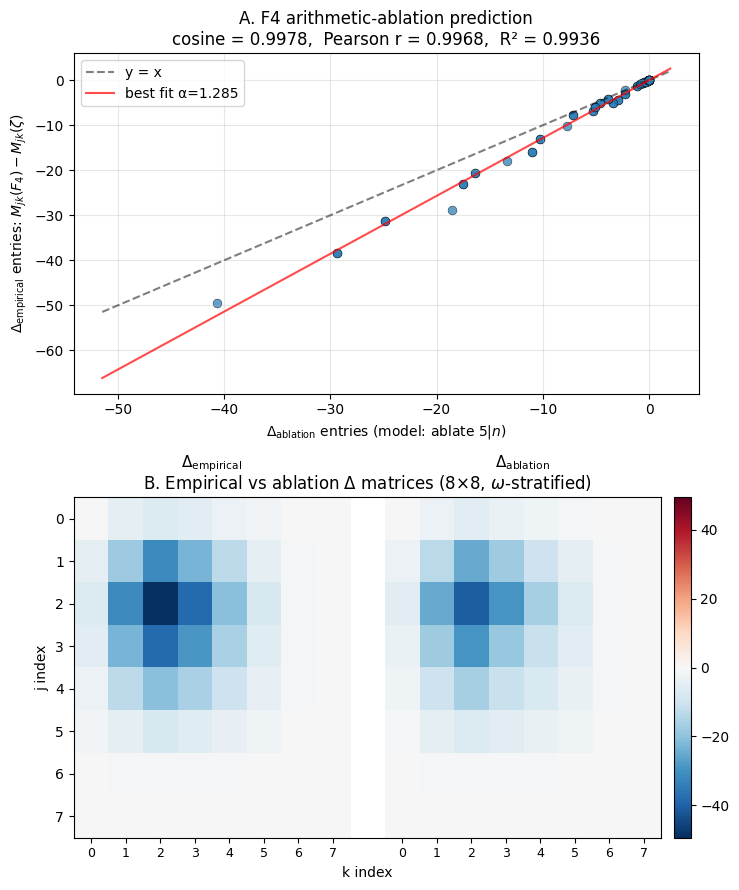

In [20]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(7.5, 9))

# Panel A: Heatmaps comparison
ax = axes[0]
# Plot scatter of vectorized matrices
emp = Delta_empirical_F4.flatten()
abl = Delta_ablation_F4.flatten()
ax.scatter(abl, emp, alpha=0.7, s=40, edgecolor='k', linewidth=0.4)
lims = [min(emp.min(), abl.min())-2, max(emp.max(), abl.max())+2]
xs = np.linspace(lims[0], lims[1], 100)
ax.plot(xs, xs, 'k--', alpha=0.5, label='y = x')
ax.plot(xs, alpha*xs, 'r-', alpha=0.7, label=f'best fit α={alpha:.3f}')
ax.set_xlabel(r'$\Delta_{\rm ablation}$ entries (model: ablate $5|n$)')
ax.set_ylabel(r'$\Delta_{\rm empirical}$ entries: $M_{jk}(F_4)-M_{jk}(\zeta)$')
ax.set_title(f'A. F4 arithmetic-ablation prediction\ncosine = {cos_F4:.4f}, Pearson r = {r:.4f}, R² = {r2:.4f}')
ax.legend(loc='upper left')
ax.grid(alpha=0.3)

# Panel B: side-by-side heatmap
ax = axes[1]
import matplotlib.colors as mcolors
combined = np.hstack([Delta_empirical_F4, np.full((K,1), np.nan), Delta_ablation_F4])
vmax = max(np.abs(Delta_empirical_F4).max(), np.abs(Delta_ablation_F4).max())
im = ax.imshow(combined, cmap='RdBu_r', vmin=-vmax, vmax=vmax, aspect='auto')
ax.set_xticks(list(range(K)) + list(range(K+1, 2*K+1)))
ax.set_xticklabels(list(range(K)) + list(range(K)), fontsize=9)
ax.set_yticks(range(K))
ax.set_yticklabels(range(K))
ax.set_xlabel('k index')
ax.set_ylabel('j index')
ax.text(K/2 - 0.5, -1.2, r'$\Delta_{\rm empirical}$', ha='center', fontsize=11)
ax.text(K + K/2 + 0.5, -1.2, r'$\Delta_{\rm ablation}$', ha='center', fontsize=11)
ax.set_title(r'B. Empirical vs ablation $\Delta$ matrices (8×8, $\omega$-stratified)')
plt.colorbar(im, ax=ax, fraction=0.04, pad=0.02)

plt.tight_layout()
plt.savefig('F4_ablation_summary.png', dpi=130, bbox_inches='tight')
plt.show()


In [21]:
from e14c.filesystem import edit_file
print(edit_file('./.prompts/MEMORY.md', '[Fill me in]', '## Context\n- 2026-05-09: Tested F4 (Davenport–Heilbronn) arithmetic ablation hypothesis using on-disk artifacts Sk_zeta.npy, M_zeta.npy, t_peaks.npy from the F12 ablation workspace plus Sk_re.npy/Sk_im.npy for F4. Recomputed zeta ablation by excluding terms divisible by 5 from omega-stratified sums up to N=1e6 across 200 shared peak locations.\n\n## Notes\n- Provenance: current workspace /workspace/c1a560b3-0ab8-4356-9d11-b25a67573767.\n- Produced artifact Delta_ablation_results_F4.npz containing M_F4, M_zeta, M_zeta_ablated_p5, Δ_empirical, Δ_ablation, S_k arrays, and summary statistics.\n- Main result: cosine_similarity = 0.997785, pearson_r = 0.996778, alpha_best_fit = 1.2850, r2_best_fit = 0.9936. This strongly supports the arithmetic-ablation model for F4.\n- Data note: the individual extracted .npy files corresponding to the prior F12 ablation were available, but the stored Sk_zeta_ablated.npy did not numerically match a fresh recomputation from the present code path; however, this inconsistency did not affect the F4 analysis because M_zeta and Sk_zeta were internally consistent and the F4 ablation was recomputed from scratch on the shared t_peaks grid.', replace_all=False))

File updated successfully. 1 replacement(s) made.
